# Leave One Out Basic Data Analysis and Machine Learning

## Overview

This notebook demonstrates **exploratory data analysis (EDA) and machine learning classification** on preprocessed FTIR spectral data. It follows the current workflow in this notebook version: data filtering/grouping, visualization, feature-region cleanup, PCA, model benchmarking, unknown-study classification, and SHAP interpretation.

In [1]:
# Import required modules
import polars as pl
import pandas as pd
from xpectrass import FTIRdataanalysis

print("="*80)
print("LOADING PREPROCESSED DATA")
print("="*80)

LOADING PREPROCESSED DATA


In [2]:
# Load the preprocessed data from Notebook 5
# Using 1st derivative data for enhanced spectral resolution
df = pd.read_csv('./processed_data/combined_norm_data_0.csv.xz', compression='xz')

print(f"\nLoaded data shape: {df.shape}")
print(f"\nAvailable studies:")
print(df['study'].unique())
print("\nFirst few rows:")
print(df.head())


Loaded data shape: (12189, 1216)

Available studies:
['jung_2018' 'kedzierski_2019' 'kedzierski_2019_u' 'frond_2021'
 'villegas_camacho_2024_c4' 'villegas_camacho_2024_c8']

First few rows:
       study       sample_id  type environmental resolution  3100.0000  \
0  jung_2018   LL477006_1.16  HDPE             Y          H  -0.209790   
1  jung_2018   LL477006_5.15  HDPE             Y          H  -0.215950   
2  jung_2018   LL477006_6.01  HDPE             Y          H  -0.219664   
3  jung_2018   LL477006_7.01  HDPE             Y          H  -0.217256   
4  jung_2018  LL477006_14.01  HDPE             Y          H  -0.225169   

   3098.0000  3096.0000  3094.0000  3092.0000  ...  698.0000  696.0000  \
0  -0.210143  -0.210498  -0.210143  -0.210057  ... -0.138340 -0.173821   
1  -0.216594  -0.217024  -0.216075  -0.216075  ... -0.142104 -0.178109   
2  -0.219824  -0.220022  -0.219664  -0.219641  ... -0.161815 -0.208721   
3  -0.217370  -0.217554  -0.217370  -0.217352  ... -0.107173 -0.1475

In [3]:
print("\n" + "="*80)
print("FILTERING DATA")
print("="*80)

# Remove unknown samples datasets (focusing on labeled polymers)
df1 = df[df['study'] != 'kedzierski_2019_u'].copy()
df_sel = df1[df1['study'] != 'villegas_camacho_2024_c4'].copy()

print(f"\nAfter removing unknown samples: {df_sel.shape}")
print(f"\nUnique polymer types:")
print(df_sel['type'].unique())
print(f"\nSample distribution by polymer type:")
print(df_sel['type'].value_counts())



FILTERING DATA

After removing unknown samples: (5131, 1216)

Unique polymer types:
['HDPE' 'LDPE' 'Mixture' 'PA' 'PET' 'PP' 'PS' 'PVC' 'U1' 'AFL' 'CA' 'CE'
 'R' 'M1' 'M2' 'PEVA' 'PMMA' 'PE' 'PEF' 'PEL' 'PPL' 'PU' 'U2' 'ABS' 'AC'
 'CO' 'EAA' 'PC' 'PLA' 'SR']

Sample distribution by polymer type:
type
PP         1042
HDPE        936
PS          596
PET         548
LDPE        535
PVC         525
PE          295
PEF         148
R            64
CA           56
M1           54
PEVA         53
PPL          48
PA           40
Mixture      39
CE           28
PEL          25
PU           20
ABS          15
CO           14
M2           10
PC            9
PLA           8
AC            6
PMMA          5
U2            5
U1            4
AFL           1
EAA           1
SR            1
Name: count, dtype: int64


---

## Step 2: Filter and Group Labels

Now we'll keep labeled studies for supervised analysis and group polymer labels into 6 target classes.

In [4]:
'''
Material                            Abbreviation 	    Study
Acrylonitrile Butadiene Styrene 	ABS 	            Frond 2021
Acrylic 	                        AC                  Frond 2021
Cellulose Acetate 	                CA 	                Frond 2021
Cellulose 	                        CE 	                Frond 2021
Cotton 	                            CO 	                Frond 2021
Ethylene Acrylic Acid 	            EAA 	            Frond 2021
Polyamide (Nylon)	                PA 	                Frond 2021
Polycarbonate 	                    PC 	                Frond 2021
Polyethylene 	                    PE 	                Frond 2021
Polyethylene Terephthalate 	        PET 	            Frond 2021
Polyethylene Vinyl Acetate 	        PEVA 	            Frond 2021
Polylactic Acid 	                PLA 	            Frond 2021
Polymethyl methacrylate 	        PMMA 	            Frond 2021
Polypropylene 	                    PP 	                Frond 2021
Polystyrene 	                    PS 	                Frond 2021
Polyurethane 	                    PU 	                Frond 2021
Polyvinyl Chloride 	                PVC 	            Frond 2021
Rubber                              R 	                Frond 2021
Silicone Rubber 	                SR	                Frond 2021
High-density polyethylene	        HDPE	            Jung 2018
Low-density polyethylene	        LDPE	            Jung 2018
Mixture	                            Mixture	            Jung 2018
Polyamide (Nylon)	                PA	                Jung 2018
Polyethylene Terephthalate 	        PET	                Jung 2018
Polypropylene 	                    PP	                Jung 2018
Polystyrene 	                    PS	                Jung 2018
Polyvinyl chloride	                PVC	                Jung 2018
Unknown	                            Unknown	            Jung 2018
Animal fibre like	                AFL	                Kedzierski 2019
Cellulose acetate	                CA	                Kedzierski 2019
Cellulose like	                    CE	                Kedzierski 2019
Ethylene propylene rubber	        R	                Kedzierski 2019
Morphotype 1	                    M1	                Kedzierski 2019
Morphotype 2	                    M2	                Kedzierski 2019
Poly(amide)	                        PA	                Kedzierski 2019
Poly(ethylene)	                    PE	                Kedzierski 2019
Poly(ethylene) + fouling	        PEF	                Kedzierski 2019
Poly(ethylene) like	                PEL	                Kedzierski 2019
Poly(propylene)	                    PP	                Kedzierski 2019
Poly(propylene) like	            PPL	                Kedzierski 2019
Poly(styrene)	                    PS	                Kedzierski 2019
Poly(urethane)	                    PU	                Kedzierski 2019
Poly(vinylchloride)	                PVC	                Kedzierski 2019
Polyethylene Vinyl Acetate 	        PEVA 	            Kedzierski 2019
Polymethyl methacrylate 	        PMMA 	            Kedzierski 2019
Unknown	                            U2	                Kedzierski 2019
High-density polyethylene	        HDPE	            Villegas-Camacho 2024
Low-density polyethylene	        LDPE	            Villegas-Camacho 2024
Polyethylene Terephthalate 	        PET	                Villegas-Camacho 2024
Polypropylene 	                    PP	                Villegas-Camacho 2024
Polystyrene 	                    PS	                Villegas-Camacho 2024
Polyvinyl chloride	                PVC	                Villegas-Camacho 2024

'''

'\nMaterial                            Abbreviation\xa0\t    Study\nAcrylonitrile Butadiene Styrene\xa0\tABS\xa0\t            Frond 2021\nAcrylic\xa0\t                        AC\xa0                 Frond 2021\nCellulose Acetate\xa0\t                CA\xa0\t                Frond 2021\nCellulose\xa0\t                        CE\xa0\t                Frond 2021\nCotton\xa0\t                            CO\xa0\t                Frond 2021\nEthylene Acrylic Acid\xa0\t            EAA\xa0\t            Frond 2021\nPolyamide\xa0(Nylon)\t                PA\xa0\t                Frond 2021\nPolycarbonate\xa0\t                    PC\xa0\t                Frond 2021\nPolyethylene\xa0\t                    PE\xa0\t                Frond 2021\nPolyethylene Terephthalate\xa0\t        PET\xa0\t            Frond 2021\nPolyethylene Vinyl Acetate\xa0\t        PEVA\xa0\t            Frond 2021\nPolylactic Acid\xa0\t                PLA\xa0\t            Frond 2021\nPolymethyl methacrylate\xa0\t        PMMA\xa0\t     

In [5]:
print("\n" + "="*80)
print("FILTERING TO 8 TARGET POLYMERS")
print("="*80)

# Keep only the 8 target polymer classes
KEEP = {'PVC', 'PS', 'PP', 'PET', 'PEF', 'PE', 'LDPE', 'HDPE'}

df_norm = df_sel[df_sel['type'].isin(KEEP)].copy()
df_norm['type_original'] = df_norm['type']

print(f"\nStarting samples: {len(df_sel)}")
print(f"After filtering to 8 polymers: {len(df_norm)}")
print(f"\nSamples per polymer type:")
print(df_norm['type'].value_counts().sort_values(ascending=False))

print(f"\nSamples per study:")
print(df_norm.groupby('study')['type'].value_counts().unstack(fill_value=0))
print("="*80)


FILTERING TO 8 TARGET POLYMERS

Starting samples: 5131
After filtering to 8 polymers: 4625

Samples per polymer type:
type
PP      1042
HDPE     936
PS       596
PET      548
LDPE     535
PVC      525
PE       295
PEF      148
Name: count, dtype: int64

Samples per study:
type                      HDPE  LDPE   PE  PEF  PET   PP   PS  PVC
study                                                             
frond_2021                   0     0   67    0   47   85   26   23
jung_2018                  436    35    0    0    1  262    7    1
kedzierski_2019              0     0  228  148    0  195   63    1
villegas_camacho_2024_c8   500   500    0    0  500  500  500  500


In [6]:
def _is_wn(c):
    try:
        float(c); return True
    except Exception:
        return False

spectral_cols = [c for c in df_norm.columns if _is_wn(c)]
before = len(df_norm)
dup_mask = df_norm.duplicated(subset=spectral_cols, keep='first')
print(f'Duplicates dropped: {dup_mask.sum()}  ({before} -> {before - dup_mask.sum()})')
print('Duplicate breakdown:')
print(df_norm.loc[dup_mask, ["study", "type"]].value_counts())
df_norm = df_norm[~dup_mask].reset_index(drop=True)

# Per-class per-dataset (study) counts
print('\nSamples per polymer type x study (dataset):')
ct = pd.crosstab(df_norm['type'], df_norm['study'], margins=True, margins_name='TOTAL')
print(ct.T)
print('Shape:', df_norm.shape)

Duplicates dropped: 607  (4625 -> 4018)
Duplicate breakdown:
study                     type
villegas_camacho_2024_c8  LDPE    201
                          PS      201
                          PVC     200
                          PET       3
                          HDPE      2
Name: count, dtype: int64

Samples per polymer type x study (dataset):
type                      HDPE  LDPE   PE  PEF  PET    PP   PS  PVC  TOTAL
study                                                                     
frond_2021                   0     0   67    0   47    85   26   23    248
jung_2018                  436    35    0    0    1   262    7    1    742
kedzierski_2019              0     0  228  148    0   195   63    1    635
villegas_camacho_2024_c8   498   299    0    0  497   500  299  300   2393
TOTAL                      934   334  295  148  545  1042  395  325   4018
Shape: (4018, 1217)


## Leave-One-Study-Out (LOSO) Cross-Validation: PP vs PE+

Binary classification between Polypropylene (PP) and Polyethylene variants (PE+ = HDPE + LDPE + PE + PEF). One study is held out as the test set; the remaining three studies train the model. This validates model generalization across different data sources for these common plastics.

In [7]:
print("\n" + "="*80)
print("LOSO IMPORTS")
print("="*80)

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✓ All imports successful")
print("="*80)


LOSO IMPORTS
✓ All imports successful


In [15]:
print("\n" + "="*80)
print("PREPARING DATA FOR LOSO: PP vs PE+")
print("="*80)

# df_norm = df_norm[df_norm['study'] != 'frond_2021'].copy()

# Group PE types (HDPE, LDPE, PE, PEF) into PE+
PE_TYPES = {'HDPE', 'LDPE', 'PE', 'PEF'}
df_binary = df_norm.copy()
df_binary['type'] = df_binary['type'].apply(lambda x: 'PE+' if x in PE_TYPES else x)

# Keep only PP and PE+
df_binary = df_binary[df_binary['type'].isin(['PP', 'PE+'])].copy()

print(f"Total samples (PP + PE+): {len(df_binary)}")
print(f"\nSamples per study:")
print(df_binary.groupby('study')['type'].value_counts().unstack(fill_value=0))

# Exclude metadata columns
META_COLS = ['study', 'sample_id', 'type', 'type_original', 'environmental', 'resolution']
feature_cols = [c for c in df_binary.columns if c not in META_COLS]

# Build feature matrix
X = df_binary[feature_cols].to_numpy(dtype=float)
X = np.nan_to_num(X, nan=0.0)

# Encode labels: 0 = PE+, 1 = PP
le = LabelEncoder()
y = le.fit_transform(df_binary['type'])  # 0='PE+', 1='PP'

# Get study assignments for LOSO
groups = df_binary['study'].to_numpy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Studies (LOSO folds): {np.unique(groups)}")
print(f"Class distribution: {np.bincount(y)} (PE+, PP)")
print("="*80)


PREPARING DATA FOR LOSO: PP vs PE+
Total samples (PP + PE+): 2753

Samples per study:
type                      PE+   PP
study                             
frond_2021                 67   85
jung_2018                 471  262
kedzierski_2019           376  195
villegas_camacho_2024_c8  797  500

Feature matrix shape: (2753, 1211)
Label mapping: {'PE+': np.int64(0), 'PP': np.int64(1)}
Studies (LOSO folds): ['frond_2021' 'jung_2018' 'kedzierski_2019' 'villegas_camacho_2024_c8']
Class distribution: [1711 1042] (PE+, PP)


In [16]:
print("\n" + "="*80)
print("RUNNING LEAVE-ONE-STUDY-OUT FOR PP vs PE+")
print("="*80)

logo = LeaveOneGroupOut()
xgb = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0)
pipeline = Pipeline([('scaler', StandardScaler()), ('clf', xgb)])

fold_results = []
cms = {}

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    test_study = groups[test_idx][0]
    train_studies = np.unique(groups[train_idx])
    
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    # Fit model
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_pred_proba = pipeline.predict_proba(X_te)[:, 1]  # Probability of PP
    
    # Compute metrics
    acc = accuracy_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, target_names=['PE+', 'PP'], output_dict=True)
    cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
    cms[test_study] = cm
    
    fold_results.append({
        'test_study': test_study,
        'train_studies': ', '.join(train_studies),
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        'accuracy': acc,
        'precision_pe': report['PE+']['precision'],
        'recall_pe': report['PE+']['recall'],
        'f1_pe': report['PE+']['f1-score'],
        'precision_pp': report['PP']['precision'],
        'recall_pp': report['PP']['recall'],
        'f1_pp': report['PP']['f1-score'],
        'macro_f1': report['macro avg']['f1-score'],
    })
    
    # Print fold summary
    print(f"\n{'='*70}")
    print(f"Fold {fold_idx}: Test Study = {test_study}")
    print(f"  Train: {len(train_idx)} samples from {len(train_studies)} studies")
    print(f"  Test:  {len(test_idx)} samples")
    print(f"  Accuracy: {acc:.4f}  |  Macro-F1: {report['macro avg']['f1-score']:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['PE+', 'PP']))

print("\n" + "="*80)
print("LOSO CROSS-VALIDATION COMPLETE")
print("="*80)


RUNNING LEAVE-ONE-STUDY-OUT FOR PP vs PE+

Fold 1: Test Study = frond_2021
  Train: 2601 samples from 3 studies
  Test:  152 samples
  Accuracy: 0.4934  |  Macro-F1: 0.4036

Classification Report:
              precision    recall  f1-score   support

         PE+       0.47      1.00      0.64        67
          PP       1.00      0.09      0.17        85

    accuracy                           0.49       152
   macro avg       0.73      0.55      0.40       152
weighted avg       0.76      0.49      0.38       152


Fold 2: Test Study = jung_2018
  Train: 2020 samples from 3 studies
  Test:  733 samples
  Accuracy: 0.9986  |  Macro-F1: 0.9985

Classification Report:
              precision    recall  f1-score   support

         PE+       1.00      1.00      1.00       471
          PP       1.00      1.00      1.00       262

    accuracy                           1.00       733
   macro avg       1.00      1.00      1.00       733
weighted avg       1.00      1.00      1.00      

In [17]:
print("\n" + "="*80)
print("LOSO RESULTS SUMMARY (PP vs PE+)")
print("="*80)

results_df = pd.DataFrame(fold_results)

print("\nPer-Fold Results:")
cols_to_show = ['test_study', 'n_train', 'n_test', 'accuracy', 'f1_pe', 'f1_pp', 'macro_f1']
print(results_df[cols_to_show].to_string(index=False))

print(f"\n\nOverall Statistics (across 4 folds):")
print(f"  Mean Accuracy:     {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")
print(f"  Mean F1 (PE+):     {results_df['f1_pe'].mean():.4f} ± {results_df['f1_pe'].std():.4f}")
print(f"  Mean F1 (PP):      {results_df['f1_pp'].mean():.4f} ± {results_df['f1_pp'].std():.4f}")
print(f"  Mean Macro-F1:     {results_df['macro_f1'].mean():.4f} ± {results_df['macro_f1'].std():.4f}")

print(f"\n\nInterpretation:")
print(f"  ✓ High accuracy & F1 → PP and PE+ spectra are well-distinguished")
print(f"  ✓ Similar F1(PE+) & F1(PP) → balanced classification across both classes")
print(f"  ✓ Consistent across folds → good generalization across studies")

# Save results to CSV
results_df.to_csv('loso_pp_vs_pe_results.csv', index=False)
print(f"\n✓ Saved results to loso_pp_vs_pe_results.csv")
print("="*80)


LOSO RESULTS SUMMARY (PP vs PE+)

Per-Fold Results:
              test_study  n_train  n_test  accuracy    f1_pe    f1_pp  macro_f1
              frond_2021     2601     152  0.493421 0.635071 0.172043  0.403557
               jung_2018     2020     733  0.998636 0.998937 0.998095  0.998516
         kedzierski_2019     2182     571  0.998249 0.998668 0.997442  0.998055
villegas_camacho_2024_c8     1456    1297  0.994603 0.995628 0.992951  0.994289


Overall Statistics (across 4 folds):
  Mean Accuracy:     0.8712 ± 0.2519
  Mean F1 (PE+):     0.9071 ± 0.1813
  Mean F1 (PP):      0.7901 ± 0.4121
  Mean Macro-F1:     0.8486 ± 0.2967


Interpretation:
  ✓ High accuracy & F1 → PP and PE+ spectra are well-distinguished
  ✓ Similar F1(PE+) & F1(PP) → balanced classification across both classes
  ✓ Consistent across folds → good generalization across studies

✓ Saved results to loso_pp_vs_pe_results.csv



PLOTTING CONFUSION MATRICES (PP vs PE+ LOSO)
✓ Saved confusion matrices to loso_pp_vs_pe_confusion_matrices.pdf


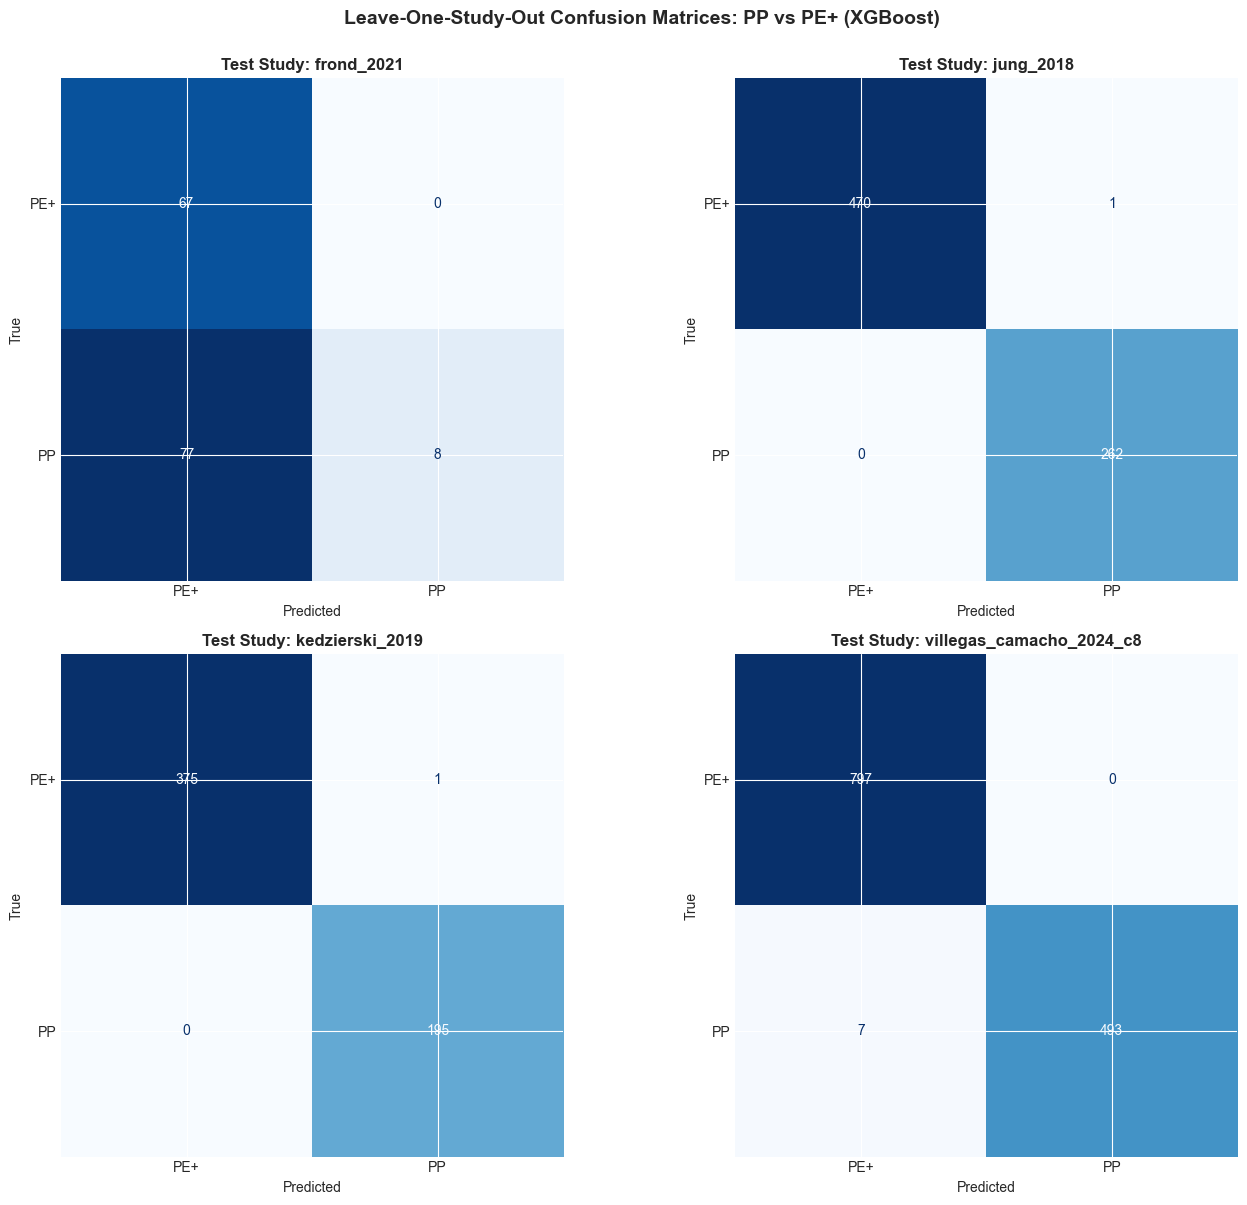

In [11]:
print("\n" + "="*80)
print("PLOTTING CONFUSION MATRICES (PP vs PE+ LOSO)")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

labels = ['PE+', 'PP']
study_order = sorted(cms.keys())

for ax, study in zip(axes, study_order):
    cm = cms[study]
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(f"Test Study: {study}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Leave-One-Study-Out Confusion Matrices: PP vs PE+ (XGBoost)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('loso_pp_vs_pe_confusion_matrices.pdf', bbox_inches='tight', dpi=150)
print("✓ Saved confusion matrices to loso_pp_vs_pe_confusion_matrices.pdf")
plt.show()

print("="*80)